### **10. Técnicas de Redução da Dimensionalidade: Uniform Manifold Approximation and Projection - UMAP** 

#### Autor: Tony Esaú de Oliveira.

##### Universidade Federal do Cariri


#### **Maldição da Dimensionalidade**

A maldição da dimensionalidade refere-se às severas dificuldades que surgem quando se trabalha com espaços que possuem muitas dimensões. À medida que a dimensionalidade ($D$) é aumentada, o número de regiões em uma grade regular cresce exponencialmente, tornando-se impraticável preencher esses espaços com dados suficientes para análises estatísticas. Geometricamente, as intuições desenvolvidas em três dimensões falham em espaços dimensionais superiores; por exemplo, em altas dimensões, a maior parte do volume de uma esfera concentra-se em uma casca fina perto de sua superfície e a massa de uma distribuição Gaussiana concentra-se em um anel fino a uma certa distância da origem.

#### **Redução de Dimensionalidade**

A redução de dimensionalidade é o processo de alterar a representação de dados complexos, originalmente descritos por um grande número de variáveis, para uma descrição de baixa dimensão usando apenas um pequeno número de parâmetros livres. Essa técnica pode ser implementada por meio de duas abordagens principais:

- **Seleção de atributos:** Identifica e seleciona o menor subconjunto de variáveis originais que melhor representam as características essenciais do problema, descartando as irrelevantes ou redundantes;
- **Extração de atributos:** Realiza transformações matemáticas ou combinações das variáveis originais para criar novas representações (como no método PCA), mantendo o máximo de informação possível em um número menor de dimensões.

A importância da redução de dimensionalidade reside em diversos fatores práticos e teóricos:

- **Eficiência Computacional e de Armazenamento:** Com a geração exponencial de dados (*Big Data*), a redução diminui a necessidade de espaço em disco e acelera drasticamente o tempo de processamento dos algoritmos;
- **Melhoria de Desempenho:** Ao eliminar redundâncias e ruídos ("informações irrelevantes"), as técnicas ajudam a evitar o sobreajuste (*overfitting*), permitindo que modelos de aprendizado de máquina alcancem maior precisão e generalização;
- **Visualização de Dados:** Projetar dados de alta dimensão em espaços de duas ou três dimensões permite que humanos visualizem estruturas, agrupamentos e padrões ocultos de forma intuitiva;
- **Estrutura Intrínseca:** Dados reais frequentemente residem em variedades não lineares (*manifolds*) de baixa dimensão embutidas no espaço de alta dimensão; a redução permite explorar essa estrutura efetiva inferior.

---

#### **Human Activity Recognition with Smartphones**

##### **Visão Geral**
- Classificação de atividades humanas (andar, sentar, etc.);
- ~3.000 amostras;
- 561 features;
- Dados de sensores de smartphone (acelerômetro e giroscópio).

##### **Origem dos Dados**
Sensores usados:
- Acelerômetro: movimento linear;
- Giroscópio: rotação.

Obs.: Celular posicionado na cintura dos usuários.

##### **Estrutura das Features**

Formato geral:

[t/f][Body/Gravity][Acc/Gyro]-[estatística]-[eixo]

##### **Componentes**

- **t / f**  
  - `t`: domínio do tempo;
  - `f`: domínio da frequência.

- **Tipo de sinal**  
  - `BodyAcc`: aceleração do corpo; 
  - `GravityAcc`: gravidade;
  - `BodyGyro`: rotação.

- **Estatísticas**  
  - `mean()`: média;
  - `std()`: desvio padrão; 
  - `energy()`: energia;
  - `entropy()`: entropia. 

- **Eixos**  
  - `X`, `Y`, `Z`


##### **Exemplo**

- `tBodyAcc-mean()-X`: média da aceleração no eixo X;  
- `fBodyGyro-energy()-Z`: energia do giroscópio no eixo Z.

##### Intuição

- Cada linha: um intervalo de movimento;
- Cada coluna: uma característica desse movimento. 

---

#### **Uniform Manifold Approximation and Projection - UMAP**

É uma técnica de aprendizado de variedades (manifold learning) para redução de dimensionalidade fundamentada em geometria Riemanniana e topologia algébrica. Formalmente, o algoritmo baseia-se em três axiomas principais: os dados estão distribuídos uniformemente em uma variedade, essa variedade é localmente conexa e o objetivo primordial é preservar a estrutura tópologica dessa variedade. A técnica utiliza aproximações locais da variedade e remenda suas representações em conjuntos simpliciais difusos (fuzzy simplicial sets) para construir uma representação topológica global dos dados.

A aplicação prática do UMAP é dividida em duas fases principais: a construção de um grafo ponderado e a otimização do layout em baixa dimensão.

1. **Construção do Grafo (Aprendizado da Topologia)**:

    - **Busca de Vizinhos**: Para cada ponto de dado, identificam-se seus $k$ vizinhos mais próximos;
    - **Normalização da Métrica Local**: Calcula-se um parâmetro $ρ_i$​ (distância até o vizinho mais próximo) para garantir a conectividade local, assegurando que cada ponto se conecte a pelo menos um outro com peso máximo;
    - **Fator de Escala** $\sigma_i$​: Define-se um fator de suavização $\sigma_i$​ de modo que a soma das afinidades locais corresponda a um valor fixo relacionado ao número de vizinhos;
    - **Simetrizacão**: Como as distâncias locais podem ser incompatíveis entre vizinhos, as arestas direcionadas são combinadas em um grafo não direcionado usando uma $\text{t-conorma probabilística}$, que interpreta os pesos como a probabilidade de existência de uma aresta.

2. **Otimização do Layout (Projeção)**:

    - **Inicialização**: O processo começa com um layout inicial, preferencialmente utilizando embutimento espectral (*spectral embedding*) derivado do Laplaciano do grafo, o que confere maior estabilidade e convergência rápida.
    - **Minimização da Entropia Cruzada**: O algoritmo busca posicionar os pontos no espaço de baixa dimensão de forma que a topologia do novo grafo (*layout*) seja a mais próxima possível da topologia do grafo original. Isso é feito minimizando a entropia cruzada difusa entre as duas representações.
    - **Forças de Atração e Repulsão**: A otimização utiliza o Gradiente Descendente Estocástico (SGD) com amostragem negativa, aplicando forças de atração ao longo das arestas do grafo e forças de repulsão entre pontos que não são vizinhos

---

In [1]:
import pandas as pd 
import numpy as np

In [2]:
dados = pd.read_csv('Conjunto_Dados/Human_Activity_Recognition_with_Smartphones.csv')

In [3]:
dados.head(10)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING
5,0.279220,-0.018620,-0.113902,-0.994455,-0.970417,-0.965316,-0.994585,-0.969481,-0.965897,-0.937856,...,-0.857565,-0.095681,0.048849,0.760684,-0.072216,-0.689816,0.294896,-0.068471,2,STANDING
6,0.279746,-0.018271,-0.104000,-0.995819,-0.976354,-0.977725,-0.995996,-0.973665,-0.979253,-0.937856,...,-0.391286,-0.309083,-0.000857,0.728514,-0.333771,-0.690085,0.295282,-0.067065,2,STANDING
7,0.274601,-0.025035,-0.116831,-0.995594,-0.982069,-0.985262,-0.995341,-0.981485,-0.984610,-0.941263,...,-0.672358,-0.025526,-0.214033,0.437640,-0.366674,-0.688785,0.295981,-0.067706,2,STANDING
8,0.272529,-0.020954,-0.114472,-0.996784,-0.975906,-0.986597,-0.997029,-0.973735,-0.985556,-0.941263,...,-0.853248,0.144626,-0.035564,-0.181800,0.087320,-0.685390,0.299394,-0.065491,2,STANDING
9,0.275746,-0.010372,-0.099776,-0.998373,-0.986933,-0.991022,-0.998663,-0.987140,-0.991084,-0.943761,...,-0.741435,0.157584,-0.033487,-0.350893,0.343146,-0.684110,0.300822,-0.064263,2,STANDING


In [4]:
dados.shape

(2947, 563)

In [5]:
dados['Activity'].unique()

mapa = {
    'STANDING': 0,
    'SITTING': 1,
    'WALKING_DOWNSTAIRS': 2,
    'LAYING': 3,
    'WALKING': 4,
    'WALKING_UPSTAIRS': 5
}

dados['Activity'] = dados['Activity'].map(mapa)

---

#### **Aplicação UMAP**

In [ ]:
#!pip install umap-learn

In [7]:
X = dados.drop('Activity', axis=1)
y = dados['Activity']

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
import umap

reducer = umap.UMAP(
    n_components=2,      # dimensão final
    n_neighbors=15,      # estrutura local/global
    min_dist=0.1,        # compactação dos clusters
    metric='euclidean',
    random_state=42
)

X_train_umap = reducer.fit_transform(X_train)
X_test_umap = reducer.transform(X_test)

c:\Users\tonye\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:
print("Original:", X_train.shape)
print("Reduzido:", X_train_umap.shape)

Original: (2357, 562)
Reduzido: (2357, 2)


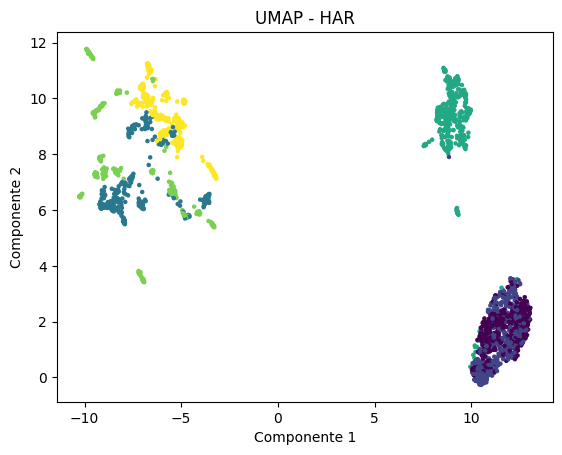

In [23]:
import matplotlib.pyplot as plt

plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='viridis', s=5)
plt.title("UMAP - HAR")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()